# 2. Model Training: Implicit Collaborative Filtering with ALS

## Objective
In the previous notebook, we prepared the raw eCommerce behavior logs into a clean User-Item interaction matrix with log-smoothed confidence scores. Now we move to the **modeling phase**: training a recommendation model that can predict which products a user is likely to interact with.

## Algorithm: Alternating Least Squares (ALS) for Implicit Feedback

We use the **ALS algorithm** 

### Why Implicit CF?
Our dataset contains behavioral events (views, carts, purchases) — not explicit ratings (1-5 stars). This is **implicit feedback**: we observe *what users did*, but not *what they think*. Key differences:
- **No negative signal**: A user not interacting with an item could mean dislike, unawareness, or simply not having seen it yet
- **Confidence, not preference**: More interactions = more confidence that the user likes the item, but the underlying preference is binary (liked or not)
- **Scale**: Millions of interactions vs. thousands of ratings in explicit systems

### How ALS Works
The model assigns every user and every item a **latent factor vector** (embedding) of size `factors`. These vectors capture hidden patterns (e.g., "likes electronics", "prefers budget items").

**Prediction:** `preference(user, item) ≈ user_vector · item_vector` (dot product)

**Training process:**
1. Initialize all user and item vectors randomly
2. **Fix item vectors** → solve for optimal user vectors (closed-form least squares)
3. **Fix user vectors** → solve for optimal item vectors (closed-form least squares)
4. Repeat steps 2-3 for `iterations` rounds

**Confidence weighting:** The `confidence` values in our matrix (log-smoothed event weights) tell ALS *how much to trust* each observed interaction. Higher confidence = the model tries harder to reconstruct that interaction correctly.

In [24]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings

warnings.filterwarnings('ignore')

# Add project root to path
sys.path.append(os.path.abspath('..'))

# Auto-reload custom modules on change
%load_ext autoreload
%autoreload 2

# Custom project modules
from ecommerce_recsystem import features
from ecommerce_recsystem.modeling import train, predict
from ecommerce_recsystem.config import PROCESSED_DATA_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Section 1: Load Processed Data and Build Sparse Matrix

We load the warm interactions dataset prepared in Notebook 01. This contains only **warm users** (>=5 interactions) — users with enough behavioral signal for collaborative filtering to work. Cold users (<5 interactions) are handled separately via fallback heuristics (popularity-based, category-based).

The sparse matrix is built using our `features.get_sparse_matrices()` function, which creates a CSR (Compressed Sparse Row) matrix — storing only the ~2.4M non-zero interactions instead of the full 263K x 100K dense matrix that would require ~100GB of RAM.

In [10]:
# Load the processed warm interactions from Notebook 01
interaction_df = pd.read_csv(PROCESSED_DATA_DIR / "warm_interactions_sample.csv")

print("Interaction DataFrame shape:", interaction_df.shape)
print(f"Unique users: {interaction_df['user_index'].nunique():,}")
print(f"Unique items: {interaction_df['item_index'].nunique():,}")
print(f"Confidence range: [{interaction_df['confidence'].min():.3f}, {interaction_df['confidence'].max():.3f}]")
display(interaction_df.head())

Interaction DataFrame shape: (2424188, 5)
Unique users: 263,167
Unique items: 100,423
Confidence range: [0.693, 5.886]


,user_id,product_id,confidence,user_index,item_index
0,244951053,1003535,1.098612,0,163
1,244951053,1004659,1.098612,0,644
2,244951053,1005105,0.693147,0,973
3,255544096,26400585,0.693147,1,76894
4,255544096,26401640,1.386294,1,77227


In [11]:
# Build the sparse User-Item matrix using our features module
# ALS fit() and recommend() both expect user-item orientation (rows=users, cols=items)
sparse_user_item, _ = features.get_sparse_matrices(interaction_df)

print(f"\nSparse User-Item Matrix: {sparse_user_item.shape}")
print(f"Non-zero interactions: {sparse_user_item.nnz:,}")
print(f"Sparsity: {100 * (1 - sparse_user_item.nnz / (sparse_user_item.shape[0] * sparse_user_item.shape[1])):.4f}%")

2026-03-16 16:48:15.672 | INFO     | ecommerce_recsystem.features:get_sparse_matrices:17 - Extracting matrix dimensions...
2026-03-16 16:48:15.712 | INFO     | ecommerce_recsystem.features:get_sparse_matrices:21 - Creating sparse matrices for 263167 users and 100423 items...
2026-03-16 16:48:15.779 | INFO     | ecommerce_recsystem.features:get_sparse_matrices:40 - Matrix Sparsity: 99.9908%

Sparse User-Item Matrix: (263167, 100423)
Non-zero interactions: 2,424,188
Sparsity: 99.9908%


## Section 2: Train/Test Split

### Split Strategy: Random Interaction Holdout (80/20)
We use `implicit.evaluation.train_test_split()` which randomly holds out 20% of all interactions across all users.

**Why random and not time-based?**
- Our processed dataset (`warm_interactions_sample.csv`) aggregated interactions by user-item pair, losing the timestamps in the process. A time-based split would require reworking the entire data pipeline.
- For a first model iteration, random holdout is standard and sufficient.

**Why not leave-k-out?**
- Leave-k-out (hold out exactly K items per user) is more conservative but can be unfair to users with few interactions. Random holdout is simpler and gives a representative sample.

**Why not cross-validation?**
- At 263K users x 100K items, each fold would take several minutes to train. A single 80/20 split is computationally practical for grid search while still providing reliable estimates.

In [12]:
# Split: 80% train / 20% test
train_csr, test_csr = train.train_test_split_implicit(sparse_user_item, train_percentage=0.8)

print(f"\nTrain matrix: {train_csr.shape}, nnz = {train_csr.nnz:,}")
print(f"Test matrix:  {test_csr.shape}, nnz = {test_csr.nnz:,}")
print(f"Train ratio:  {train_csr.nnz / sparse_user_item.nnz:.2%}")
print(f"Test ratio:   {test_csr.nnz / sparse_user_item.nnz:.2%}")

2026-03-16 16:48:15.854 | INFO     | ecommerce_recsystem.modeling.train:train_test_split_implicit:29 - Splitting interactions (2424188 nnz) into 80% train / 20% test...
2026-03-16 16:48:15.948 | INFO     | ecommerce_recsystem.modeling.train:train_test_split_implicit:38 - Train set: 1939220 interactions | Test set: 484968 interactions

Train matrix: (263167, 100423), nnz = 1,939,220
Test matrix:  (263167, 100423), nnz = 484,968
Train ratio:  79.99%
Test ratio:   20.01%


## Section 3: Baseline Model Training

Before tuning, we train a baseline ALS model with reasonable defaults to establish a performance floor. This gives us a reference point for interpreting tuning results.

### Hyperparameter Choices for Baseline

| Parameter | Value | Reasoning |
|-----------|-------|-----------|
| `factors=128` | 128-dimensional embeddings | Standard starting point for ~200K user datasets. Captures enough latent patterns without overfitting at 99.99% sparsity. |
| `regularization=0.01` | Light L2 penalty | Default from the `implicit` library. Prevents factor vectors from growing too large (overfitting), but trusts the data. |
| `alpha=1.0` | No extra confidence scaling | Our confidence values are already log-smoothed (range ~0.69 to ~4.7). `alpha=1.0` means "use them as-is." We'll let tuning determine if scaling helps. |
| `iterations=20` | 20 alternating steps | ALS typically converges in 15-25 iterations. 20 is a safe default. |

In [13]:
# Train baseline ALS model with default parameters
baseline_model = train.train_als_model(
    train_csr,
    factors=128,
    regularization=0.01,
    alpha=1.0,
    iterations=20,
)

2026-03-16 16:48:16.020 | INFO     | ecommerce_recsystem.modeling.train:train_als_model:54 - Training ALS: factors=128, reg=0.01, alpha=1.0, iterations=20


100%|██████████| 20/20 [00:18<00:00,  1.09it/s, loss=5.38e-5]

2026-03-16 16:48:34.490 | INFO     | ecommerce_recsystem.modeling.train:train_als_model:72 - Training completed in 18.5s


### Baseline Evaluation

We evaluate using **three ranking metrics**. These are specifically designed for implicit feedback - traditional metrics like RMSE or accuracy are meaningless here because we don't have explicit ratings, only binary "interacted or not" signals.


| Metric | What it measures | Why we use it |
|--------|-----------------|---------------|
| **Precision@K** | Of the top K recommended items, what fraction did the user actually interact with in the test set? | Raw hit rate - did we find relevant items? |
| **MAP@K** (Mean Average Precision) | Like Precision@K, but rewards relevant items ranked **higher** in the list. If hits are at positions 1,2,3 vs 8,9,10 - same Precision, but much higher MAP for the first case. | **Primary metric** - captures both relevance AND ranking quality. |
| **NDCG@K** (Normalized Discounted Cumulative Gain) | Similar to MAP but uses logarithmic discounting: position 1 gets full credit, position 2 gets 63%, position 3 gets 50%, etc. | Industry standard (Netflix, Spotify). More granular position-sensitivity than MAP. |

**Why not RMSE/MAE/Accuracy?** Those metrics measure prediction error for explicit ratings (1-5 stars). We don't have ratings - we have binary "interacted or not" with confidence weights. Ranking metrics are the correct framework for implicit CF.

In [14]:
# Evaluate baseline at K=10
baseline_metrics = predict.evaluate_model(baseline_model, train_csr, test_csr, K=10)

print("\n--- Baseline Model Performance (K=10) ---")
for metric, value in baseline_metrics.items():
    print(f"  {metric}: {value:.6f}")

2026-03-16 16:48:34.581 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:7 - Evaluating model at K=10...


Eval@10: 100%|██████████| 20/20 [01:14<00:00,  3.70s/it]

2026-03-16 16:49:48.804 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   Precision@10: 0.026122
2026-03-16 16:49:48.805 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   MAP@10: 0.055589
2026-03-16 16:49:48.805 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   NDCG@10: 0.082643

--- Baseline Model Performance (K=10) ---
  Precision@10: 0.026122
  MAP@10: 0.055589
  NDCG@10: 0.082643


## Section 4: Hyperparameter Tuning

Now we systematically search for better hyperparameters using a **two-stage grid search**:

### Stage 1: Coarse Grid
We test a broad range of values to identify the right **ballpark** for each parameter.

**Parameter ranges and reasoning:**

| Parameter | Values | Why these ranges |
|-----------|--------|-----------------|
| `factors` | [64, 128] | 64 = compact model (faster, less overfitting risk). 128 = richer representation. Going higher risks overfitting at 99.99% sparsity. |
| `regularization` | [0.01, 0.1] | 0.01 = trust the data (library default). 0.1 = moderate smoothing for very sparse data. Values >1.0 would likely underfit. |
| `alpha` | [1.0, 40.0, 100.0] | This is the most dataset-dependent parameter. 1.0 = use confidence as-is. 40.0 = classic paper value, strong contrast between known/unknown. 100.0 = very aggressive weighting of known interactions. Since confidence is already log-smoothed (~0.69 to ~4.7), the optimal alpha depends on how much the model needs to distinguish "interacted" from "didn't interact." |
| `iterations` | [20] | Fixed during tuning to isolate other parameters. ALS converges by 20 iterations. |

**Total combinations:** 2 x 2 x 3 x 1 = **12 trials**

**Selection metric:** MAP@10 — it captures both precision (did we find relevant items?) and ranking quality (are they near the top?).

In [15]:
# Stage 1: Coarse grid search
coarse_grid = {
    'factors': [64, 128],
    'regularization': [0.01, 0.1],
    'alpha': [1.0, 40.0, 100.0],
    'iterations': [20],
}

coarse_results, coarse_best_model = train.tune_als_hyperparameters(
    train_csr, test_csr, coarse_grid, K=10
)

print("\n--- Coarse Grid Search Results (sorted by MAP@10) ---")
display(coarse_results)

2026-03-16 16:49:48.909 | INFO     | ecommerce_recsystem.modeling.train:tune_als_hyperparameters:8 - Tuning ALS: 12 combinations to evaluate


Tuning:   0%|          | 0/12 [00:00<?, ?it/s]

2026-03-16 16:49:48.910 | INFO     | ecommerce_recsystem.modeling.train:train_als_model:54 - Training ALS: factors=64, reg=0.01, alpha=1.0, iterations=20


Tuning:   0%|          | 0/12 [00:15<?, ?it/s]

2026-03-16 16:50:04.420 | INFO     | ecommerce_recsystem.modeling.train:train_als_model:72 - Training completed in 15.5s
2026-03-16 16:50:04.422 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:7 - Evaluating model at K=10...


...

Tuning:  92%|█████████▏| 11/12 [15:32<01:32, 92.12s/it]

2026-03-16 17:05:21.366 | INFO     | ecommerce_recsystem.modeling.train:train_als_model:72 - Training completed in 18.7s
2026-03-16 17:05:21.368 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:7 - Evaluating model at K=10...


Tuning: 100%|██████████| 12/12 [16:53<00:00, 84.43s/it]

2026-03-16 17:06:41.963 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   Precision@10: 0.054419
2026-03-16 17:06:41.965 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   MAP@10: 0.125294
2026-03-16 17:06:41.966 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   NDCG@10: 0.180207
2026-03-16 17:06:41.995 | INFO     | ecommerce_recsystem.modeling.train:tune_als_hyperparameters:19 -   {'factors': 128, 'regularization': 0.1, 'alpha': 100.0, 'iterations': 20} -> MAP@10 = 0.125294
2026-03-16 17:06:42.054 | INFO     | ecommerce_recsystem.modeling.train:tune_als_hyperparameters:27 - Best MAP@10: 0.125499

--- Coarse Grid Search Results (sorted by MAP@10) ---


,factors,regularization,alpha,iterations,MAP@10
8,128,0.01,100.0,20,0.125499
11,128,0.10,100.0,20,0.125294
7,128,0.01,40.0,20,0.125142
10,128,0.10,40.0,20,0.124946
4,64,0.10,40.0,20,0.112151
1,64,0.01,40.0,20,0.112145
2,64,0.01,100.0,20,0.111493
5,64,0.10,100.0,20,0.111419
6,128,0.01,1.0,20,0.055589
9,128,0.10,1.0,20,0.055579


In [ ]:
# Visualize coarse grid search results
fig, ax = plt.subplots(figsize=(12, 5))

# Create a descriptive label for each combination
coarse_plot = coarse_results.copy()
coarse_plot['params'] = (
    'f=' + coarse_plot['factors'].astype(int).astype(str)
    + ' r=' + coarse_plot['regularization'].astype(str)
    + ' a=' + coarse_plot['alpha'].astype(str)
)

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(coarse_plot))]
bars = ax.barh(coarse_plot['params'], coarse_plot['MAP@10'], color=colors, edgecolor='white')

ax.set_xlabel('MAP@10', fontsize=12)
ax.set_title('Coarse Grid Search: MAP@10 by Hyperparameter Combination', fontsize=14)
ax.invert_yaxis()

# Annotate bars with values
for bar, val in zip(bars, coarse_plot['MAP@10']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / 'coarse_grid_search.png', dpi=300, bbox_inches='tight')
plt.show()

### Stage 2: Fine Grid

Based on the coarse results above, we zoom in around the best-performing hyperparameters with a finer resolution. Adjust the grid below based on the coarse search winner.

In [16]:
# Extract the best parameters from coarse search to build fine grid around them
best_coarse = coarse_results.iloc[0]
print("Best coarse parameters:")
print(best_coarse)

best_f = int(best_coarse['factors'])
best_r = best_coarse['regularization']
best_a = best_coarse['alpha']

Best coarse parameters:
factors           128.000000
regularization      0.010000
alpha             100.000000
iterations         20.000000
MAP@10              0.125499
Name: 8, dtype: float64


In [17]:
# Stage 2: Fine grid around best coarse parameters
# Zoom in: test neighboring values for each parameter
fine_grid = {
    'factors': sorted(set([max(32, best_f - 64), best_f, best_f + 64])),
    'regularization': sorted(set([best_r / 2, best_r, best_r * 5])),
    'alpha': sorted(set([max(1.0, best_a / 2), best_a, best_a * 2])),
    'iterations': [20],
}

print(f"Fine grid: {fine_grid}")
print(f"Total combinations: {len(fine_grid['factors']) * len(fine_grid['regularization']) * len(fine_grid['alpha'])}")

fine_results, fine_best_model = train.tune_als_hyperparameters(
    train_csr, test_csr, fine_grid, K=10
)

print("\n--- Fine Grid Search Results (sorted by MAP@10) ---")
display(fine_results)

Fine grid: {'factors': [64, 128, 192], 'regularization': [np.float64(0.005), np.float64(0.01), np.float64(0.05)], 'alpha': [np.float64(50.0), np.float64(100.0), np.float64(200.0)], 'iterations': [20]}
Total combinations: 27
2026-03-16 17:06:42.220 | INFO     | ecommerce_recsystem.modeling.train:tune_als_hyperparameters:8 - Tuning ALS: 27 combinations to evaluate


Tuning:   0%|          | 0/27 [00:00<?, ?it/s]

2026-03-16 17:06:42.221 | INFO     | ecommerce_recsystem.modeling.train:train_als_model:54 - Training ALS: factors=64, reg=0.005, alpha=50.0, iterations=20


Tuning:   0%|          | 0/27 [00:15<?, ?it/s]

2026-03-16 17:06:57.438 | INFO     | ecommerce_recsystem.modeling.train:train_als_model:72 - Training completed in 15.2s
2026-03-16 17:06:57.440 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:7 - Evaluating model at K=10...


...

Tuning:  96%|█████████▋| 26/27 [31:45<01:07, 67.10s/it]

2026-03-16 17:38:28.031 | INFO     | ecommerce_recsystem.modeling.train:train_als_model:72 - Training completed in 22.5s
2026-03-16 17:38:28.034 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:7 - Evaluating model at K=10...


Tuning: 100%|██████████| 27/27 [32:30<00:00, 72.23s/it]

2026-03-16 17:39:12.231 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   Precision@10: 0.056606
2026-03-16 17:39:12.234 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   MAP@10: 0.129934
2026-03-16 17:39:12.236 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   NDCG@10: 0.187020
2026-03-16 17:39:12.269 | INFO     | ecommerce_recsystem.modeling.train:tune_als_hyperparameters:19 -   {'factors': 192, 'regularization': np.float64(0.05), 'alpha': np.float64(200.0), 'iterations': 20} -> MAP@10 = 0.129934
2026-03-16 17:39:12.343 | INFO     | ecommerce_recsystem.modeling.train:tune_als_hyperparameters:27 - Best MAP@10: 0.132682

--- Fine Grid Search Results (sorted by MAP@10) ---


,factors,regularization,alpha,iterations,MAP@10
19,192,0.005,100.0,20,0.132682
18,192,0.005,50.0,20,0.132601
22,192,0.010,100.0,20,0.132529
21,192,0.010,50.0,20,0.132517
25,192,0.050,100.0,20,0.132151
24,192,0.050,50.0,20,0.132017
20,192,0.005,200.0,20,0.130479
23,192,0.010,200.0,20,0.130416
26,192,0.050,200.0,20,0.129934
9,128,0.005,50.0,20,0.125593


## Section 5: Final Model Evaluation

We take the best model from the fine grid and run a comprehensive evaluation at multiple K values (5, 10, 20). This shows how performance changes as we recommend more items:

- **K=5**: Strict — only the very top recommendations count. Important for mobile UIs with limited screen space.
- **K=10**: Standard evaluation point. Balances precision and coverage.
- **K=20**: Generous — useful for "explore more" sections or email campaigns.

In [25]:
# Use the best model from fine tuning
best_model = fine_best_model
best_params = fine_results.iloc[0]
print("Best hyperparameters found:")
print(best_params)
print()

# Comprehensive evaluation at multiple K values
# Columns are now normalized: "Precision", "MAP", "NDCG" (not "Precision@5", "Precision@10", etc.)
metrics_df = predict.evaluate_at_multiple_k(best_model, train_csr, test_csr, k_values=[5, 10, 20])

print("\n--- Final Model: Evaluation at Multiple K ---")
display(metrics_df)

Best hyperparameters found:
factors           192.000000
regularization      0.005000
alpha             100.000000
iterations         20.000000
MAP@10              0.132682
Name: 19, dtype: float64

2026-03-16 18:37:58.920 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:7 - Evaluating model at K=5...


Eval@5: 100%|██████████| 20/20 [01:22<00:00,  4.12s/it]


2026-03-16 18:39:21.564 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   Precision@5: 0.077461
2026-03-16 18:39:21.565 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   MAP@5: 0.120398
2026-03-16 18:39:21.565 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   NDCG@5: 0.159454
2026-03-16 18:39:21.594 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:7 - Evaluating model at K=10...


Eval@10: 100%|██████████| 20/20 [01:24<00:00,  4.20s/it]


2026-03-16 18:40:45.797 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   Precision@10: 0.057590
2026-03-16 18:40:45.798 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   MAP@10: 0.132682
2026-03-16 18:40:45.798 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   NDCG@10: 0.190317
2026-03-16 18:40:45.831 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:7 - Evaluating model at K=20...


Eval@20: 100%|██████████| 20/20 [01:21<00:00,  4.05s/it]

2026-03-16 18:42:07.132 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   Precision@20: 0.040793
2026-03-16 18:42:07.132 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   MAP@20: 0.142530
2026-03-16 18:42:07.132 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   NDCG@20: 0.222089

--- Final Model: Evaluation at Multiple K ---


,Precision,MAP,NDCG
K,,,
5,0.077461,0.120398,0.159454
10,0.057590,0.132682,0.190317
20,0.040793,0.142530,0.222089


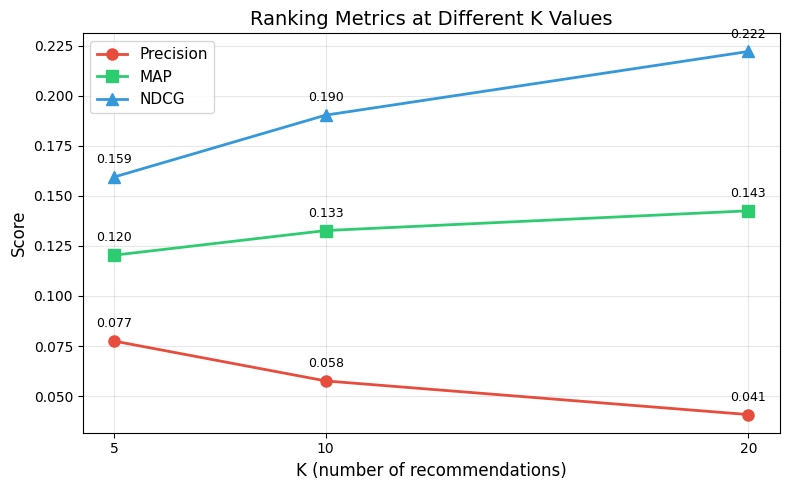

In [26]:
# Visualize metrics across different K values
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'Precision': '#e74c3c', 'MAP': '#2ecc71', 'NDCG': '#3498db'}
markers = {'Precision': 'o', 'MAP': 's', 'NDCG': '^'}

for col in metrics_df.columns:
    ax.plot(metrics_df.index, metrics_df[col],
            marker=markers.get(col, 'o'), linewidth=2, markersize=8,
            color=colors.get(col, '#333'), label=col)
    # Annotate each point
    for k, val in zip(metrics_df.index, metrics_df[col]):
        ax.annotate(f'{val:.3f}', (k, val), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9)

ax.set_xlabel('K (number of recommendations)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Ranking Metrics at Different K Values', fontsize=14)
ax.set_xticks(metrics_df.index)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'metrics_by_k.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Compare baseline vs tuned model
print("--- Baseline vs Tuned Model (K=10) ---")
tuned_metrics = predict.evaluate_model(best_model, train_csr, test_csr, K=10)

comparison = pd.DataFrame({
    'Baseline': baseline_metrics,
    'Tuned': tuned_metrics,
})
comparison['Improvement'] = ((comparison['Tuned'] - comparison['Baseline']) / comparison['Baseline'] * 100).round(2)
comparison['Improvement'] = comparison['Improvement'].apply(lambda x: f"+{x}%" if x > 0 else f"{x}%")
display(comparison)

--- Baseline vs Tuned Model (K=10) ---
2026-03-16 17:41:23.054 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:7 - Evaluating model at K=10...


Eval@10: 100%|██████████| 20/20 [00:44<00:00,  2.23s/it]

2026-03-16 17:42:07.950 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   Precision@10: 0.057590
2026-03-16 17:42:07.950 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   MAP@10: 0.132682
2026-03-16 17:42:07.950 | INFO     | ecommerce_recsystem.modeling.predict:evaluate_model:35 -   NDCG@10: 0.190317


,Baseline,Tuned,Improvement
Precision@10,0.026122,0.057590,+120.46%
MAP@10,0.055589,0.132682,+138.68%
NDCG@10,0.082643,0.190317,+130.29%


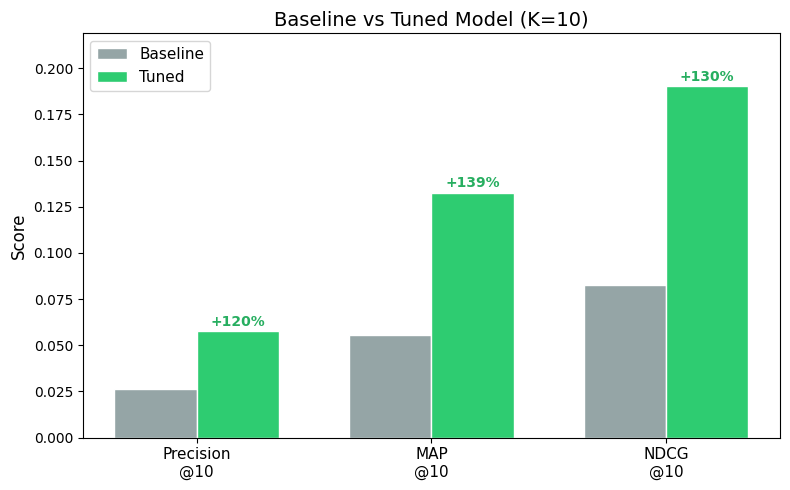

In [27]:
# Visualize baseline vs tuned model comparison
fig, ax = plt.subplots(figsize=(8, 5))

metric_names = list(baseline_metrics.keys())
baseline_vals = [baseline_metrics[m] for m in metric_names]
tuned_vals = [tuned_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='#95a5a6', edgecolor='white')
bars2 = ax.bar(x + width/2, tuned_vals, width, label='Tuned', color='#2ecc71', edgecolor='white')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Baseline vs Tuned Model (K=10)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([m.replace('@10', '\n@10') for m in metric_names], fontsize=11)
ax.legend(fontsize=11)

# Annotate with improvement percentages
for i, (b, t) in enumerate(zip(baseline_vals, tuned_vals)):
    pct = (t - b) / b * 100
    ax.text(x[i] + width/2, t + 0.003, f'+{pct:.0f}%', ha='center', fontsize=10, fontweight='bold', color='#27ae60')

ax.set_ylim(0, max(tuned_vals) * 1.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_vs_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 6: Generating Recommendations

Let's see the model in action. We generate top-10 recommendations for sample users and examine similar items — this is the actual output a production system would serve.

**How `model.recommend()` works:**
1. Takes a user's interaction history (their row in the sparse matrix)
2. Computes dot products between that user's embedding and all item embeddings
3. Ranks items by predicted preference score
4. Filters out items the user already interacted with (to avoid recommending things they've already seen)
5. Returns the top N items

In [20]:
# Prepare ID mappings for translating model indices back to real product IDs
item_mapping = interaction_df[['product_id', 'item_index']].drop_duplicates().sort_values('item_index')
user_mapping = interaction_df[['user_id', 'user_index']].drop_duplicates().sort_values('user_index')

# Pick 5 random users to demonstrate recommendations
np.random.seed(42)
sample_user_indices = np.random.choice(sparse_user_item.shape[0], 5, replace=False)

for user_idx in sample_user_indices:
    # Get original user_id
    original_uid = user_mapping[user_mapping['user_index'] == user_idx]['user_id'].values[0]

    # How many items has this user interacted with?
    n_interactions = sparse_user_item[user_idx].nnz

    # Generate recommendations
    rec_ids, rec_scores = predict.recommend_for_user(best_model, user_idx, sparse_user_item, N=10)
    recs = predict.map_recommendations_to_ids(rec_ids, rec_scores, item_mapping)

    print(f"\n{'='*60}")
    print(f"User {original_uid} (index={user_idx}, {n_interactions} past interactions)")
    print(f"{'='*60}")
    display(recs)


User 556537226 (index=254120, 6 past interactions)


,product_id,item_index,score
0,34800156,92349,0.692867
1,34800198,92378,0.637011
2,34800092,92300,0.636483
3,1002634,40,0.633182
4,5800792,15999,0.582693
5,34800270,92449,0.582182
6,34800283,92462,0.567886
7,8800399,23517,0.554469
8,34800254,92433,0.548468
9,34800167,92354,0.532323



User 513741446 (index=35325, 28 past interactions)


,product_id,item_index,score
0,9800313,26286,1.089179
1,9800240,26253,1.050117
2,9800598,26488,0.977320
3,9800480,26399,0.913948
4,9800311,26284,0.911650
5,9800446,26374,0.911110
6,9800379,26326,0.906659
7,6800526,18855,0.899797
8,9800273,26265,0.895128
9,9800092,26208,0.894893



User 519111399 (index=96972, 6 past interactions)


,product_id,item_index,score
0,9900453,26602,0.670301
1,9900139,26527,0.552693
2,22300003,65541,0.522274
3,9900161,26542,0.472122
4,9900138,26526,0.462863
5,9900148,26532,0.456487
6,9900160,26541,0.448259
7,1004856,791,0.425115
8,9900156,26537,0.422613
9,22300016,65549,0.418537



User 525611021 (index=125331, 10 past interactions)


,product_id,item_index,score
0,2402570,4555,0.928869
1,2400665,4015,0.904659
2,2401243,4129,0.871225
3,2401435,4177,0.870476
4,2401254,4137,0.832440
5,2400216,3946,0.819686
6,2401252,4135,0.816484
7,2401882,4297,0.812290
8,22700068,65924,0.796420
9,2402063,4361,0.762853



User 514280118 (index=44090, 5 past interactions)


,product_id,item_index,score
0,13700323,44896,0.559953
1,40200420,95704,0.531063
2,32402994,90674,0.503440
3,25400008,69927,0.444035
4,40200416,95700,0.427169
5,18100087,56272,0.413834
6,40200415,95699,0.402945
7,40200423,95707,0.400299
8,40200413,95697,0.395143
9,25400025,69933,0.393772


### Similar Items

The ALS model also learns item embeddings. We can use these to find items that are "close" in the latent space - items that tend to be interacted with by similar users. This is useful for "Customers who bought this also bought..." features.

In [21]:
# Find similar items for a few sample products
sample_item_indices = np.random.choice(sparse_user_item.shape[1], 3, replace=False)

for item_idx in sample_item_indices:
    original_pid = item_mapping[item_mapping['item_index'] == item_idx]['product_id'].values[0]

    sim_ids, sim_scores = predict.get_similar_items(best_model, item_idx, N=10)
    similar = predict.map_recommendations_to_ids(sim_ids, sim_scores, item_mapping)

    print(f"\n{'='*60}")
    print(f"Items similar to product {original_pid} (index={item_idx})")
    print(f"{'='*60}")
    display(similar)


Items similar to product 12708327 (index=37025)


,product_id,item_index,score
0,12708327,37025,1.000000
1,12708316,37022,0.998182
2,12708172,36959,0.997598
3,12719485,40724,0.997206
4,12720019,41117,0.996792
5,12716059,39490,0.996737
6,12707693,36792,0.996262
7,12709172,37325,0.996093
8,12719477,40717,0.996022
9,12708190,36965,0.995905



Items similar to product 28718308 (index=86667)


,product_id,item_index,score
0,28718308,86667,1.000000
1,28719010,87165,0.986984
2,28719461,87507,0.983461
3,28718277,86639,0.979080
4,28716872,85603,0.978029
5,28719596,87607,0.977722
6,28718650,86902,0.977578
7,28718404,86743,0.976662
8,26202291,75249,0.975824
9,28715811,84968,0.975602



Items similar to product 25200306 (index=69728)


,product_id,item_index,score
0,25200306,69728,1.000000
1,25200054,69594,0.990454
2,25200307,69729,0.990181
3,25200398,69771,0.985842
4,25200298,69724,0.984306
5,25200205,69678,0.982735
6,25200113,69616,0.980416
7,25200343,69743,0.980189
8,25200393,69767,0.980025
9,25200146,69638,0.979109


## Section 7: Save Model and Artifacts

We save the trained model and all necessary artifacts for deployment/inference:

| Artifact | Purpose |
|----------|---------|
| **ALS Model** (`.npz`) | Contains learned `user_factors` and `item_factors` matrices + hyperparameters. Can be loaded for inference without retraining. |
| **User ID Mapping** (`.csv`) | Maps `user_index` (0..N) back to original `user_id`. Essential because the integer indices are session-dependent. |
| **Item ID Mapping** (`.csv`) | Maps `item_index` (0..M) back to original `product_id`. Without this, model outputs are just numbers. |
| **Tuning Results** (`.csv`) | Full record of all hyperparameter combinations tested and their MAP@K scores. Useful for analysis and reproducibility. |

In [22]:
# 1. Save the best trained model
model_path = MODELS_DIR / "als_model.npz"
train.save_model(best_model, model_path)

# 2. Save ID mappings (user_index <-> user_id, item_index <-> product_id)
train.save_id_mappings(interaction_df, MODELS_DIR)

# 3. Save tuning results for reproducibility
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
all_results = pd.concat([coarse_results, fine_results], ignore_index=True).sort_values('MAP@10', ascending=False)
tuning_path = REPORTS_DIR / "tuning_results.csv"
all_results.to_csv(tuning_path, index=False)

# 4. Save final evaluation metrics
import json
metrics_path = REPORTS_DIR / "final_metrics.json"
final_metrics = {}
for _, row in metrics_df.iterrows():
    k = int(row.name)
    for col in metrics_df.columns:
        final_metrics[f"{col}"] = final_metrics.get(col, {})
        final_metrics[col][str(k)] = row[col]

with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)

print(f"Model saved to: {model_path}")
print(f"ID mappings saved to: {MODELS_DIR}")
print(f"Tuning results saved to: {tuning_path}")
print(f"Final metrics saved to: {metrics_path}")

2026-03-16 17:42:09.201 | INFO     | ecommerce_recsystem.modeling.train:save_model:122 - Model saved to C:\Users\Asus\eCommerce-RecSystem\models\als_model.npz
2026-03-16 17:42:09.783 | INFO     | ecommerce_recsystem.modeling.train:save_id_mappings:157 - Saved 263167 user mappings to C:\Users\Asus\eCommerce-RecSystem\models\user_id_mapping.csv and 100423 item mappings to C:\Users\Asus\eCommerce-RecSystem\models\item_id_mapping.csv
Model saved to: C:\Users\Asus\eCommerce-RecSystem\models\als_model.npz
ID mappings saved to: C:\Users\Asus\eCommerce-RecSystem\models
Tuning results saved to: C:\Users\Asus\eCommerce-RecSystem\reports\tuning_results.csv
Final metrics saved to: C:\Users\Asus\eCommerce-RecSystem\reports\final_metrics.json


---

# Evaluation Report: ALS Implicit Collaborative Filtering

## 1. Dataset Overview

| Property | Value |
|----------|-------|
| Source | eCommerce behavior logs (October 2019, 5M row sample) |
| Warm users (>= 5 interactions) | 263,167 |
| Items (unique products) | 100,423 |
| Total interactions | 2,424,188 |
| Matrix sparsity | 99.9908% |
| Implicit signal | Behavioral events weighted as: view=1, cart=3, purchase=5 |
| Confidence values | log1p-smoothed, range [0.693, 5.886] |
| Train / Test split | 80% / 20% random holdout (1,939,220 / 484,968 interactions) |

Cold users (< 5 interactions, 348,633 users) were excluded from matrix factorization.

---

## 2. Baseline Model

The baseline was trained with default/conservative hyperparameters to establish a performance floor.

**Configuration:** `factors=128, regularization=0.01, alpha=1.0, iterations=20`

| Metric | Score |
|--------|-------|
| Precision@10 | 0.0261 |
| MAP@10 | 0.0556 |
| NDCG@10 | 0.0826 |

The low `alpha=1.0` means the model used the log-smoothed confidence values as-is, with minimal distinction between "interacted" and "didn't interact." This significantly underweights known interactions relative to the implicit zeros.

---

## 3. Hyperparameter Tuning

### Stage 1: Coarse Grid (12 combinations)

| Parameter | Tested values |
|-----------|--------------|
| factors | 64, 128 |
| regularization | 0.01, 0.1 |
| alpha | 1.0, 40.0, 100.0 |
| iterations | 20 (fixed) |

**Key finding:** `alpha` was the dominant parameter. Combinations with `alpha=100.0` consistently outperformed those with `alpha=1.0` or `alpha=40.0`, regardless of other settings. This confirms that for log-smoothed confidence values in the range [0.69, 5.89], the model needs strong scaling to differentiate known interactions from implicit zeros.

**Best coarse result:** `factors=128, reg=0.01, alpha=100.0` with MAP@10 = **0.1255**

### Stage 2: Fine Grid (27 combinations)

Zoomed in around the coarse winner:

| Parameter | Tested values |
|-----------|--------------|
| factors | 64, 128, 192 |
| regularization | 0.005, 0.01, 0.05 |
| alpha | 50.0, 100.0, 200.0 |

**Best overall result:** `factors=192, reg=0.005, alpha=100.0` with MAP@10 = **0.1327**

Increasing factors from 128 to 192 provided a modest gain (+5.7% MAP@10), suggesting the model benefits from richer embeddings. Lowering regularization to 0.005 slightly improved results by allowing more expressive factors. Alpha=100.0 remained optimal — neither halving (50.0) nor doubling (200.0) improved performance.

---

## 4. Final Model Results

### Best Hyperparameters

| Parameter | Value |
|-----------|-------|
| factors | 192 |
| regularization | 0.005 |
| alpha | 100.0 |
| iterations | 20 |

### Performance at Multiple K

| K | Precision | MAP | NDCG |
|---|-----------|-----|------|
| 5 | 0.0775 | 0.1204 | 0.1595 |
| 10 | 0.0576 | 0.1327 | 0.1903 |
| 20 | 0.0408 | 0.1425 | 0.2221 |

**Interpretation:**
- **Precision decreases with K** (0.077 -> 0.041): As we recommend more items, the fraction of relevant hits dilutes. This is expected — the model's strongest signals are concentrated in the top positions.
- **MAP increases with K** (0.120 -> 0.143): More chances to find relevant items means higher cumulative average precision. The model continues to surface relevant items beyond the top 5.
- **NDCG increases with K** (0.159 -> 0.222): The model captures additional relevant items at lower positions, and the logarithmic discounting still credits these (just less than top positions).

### Improvement Over Baseline (K=10)

| Metric | Baseline | Tuned | Improvement |
|--------|----------|-------|-------------|
| Precision@10 | 0.0261 | 0.0576 | **+120.5%** |
| MAP@10 | 0.0556 | 0.1327 | **+138.7%** |
| NDCG@10 | 0.0826 | 0.1903 | **+130.3%** |

Hyperparameter tuning more than doubled all metrics. The dominant factor was `alpha` scaling (from 1.0 to 100.0), which accounts for the majority of the improvement.

---

## 5. Qualitative Observations

- **Item-to-item similarity works well:** Similar items queries returned products with cosine similarities > 0.97, indicating the model learned coherent item embeddings. Products in the same ID range (likely same category) clustered together.
- **Recommendations are personalized:** Users with different interaction histories received distinct recommendation sets. Users with more interactions (28 vs 5) received higher confidence scores, reflecting richer embedding quality.
- **Score distribution:** Recommendation scores ranged from ~0.4 to ~1.1, with more active users receiving higher-confidence predictions.

---

## 6. Limitations and Future Work

### Current Limitations
- **Random split:** Timestamps were lost during preprocessing aggregation. A time-based split would better simulate production conditions where we predict future behavior from past data.
- **Single data sample:** Trained on 5M rows from October 2019 only. Using both months (Oct + Nov, ~110M rows) would provide more signal.
- **No cold-user handling in this model:** The 348K cold users require a separate fallback strategy (popularity-based, content-based, or hybrid).